# Term-Structure Models on the US Treasury Curve

**Question:** how well do the classic one-factor short-rate models reproduce the actual US Treasury curve, and what does it take to fit it exactly?

The theory is in the [README](../README.md). This notebook implements it section by section on FRED data.
Functions live in the `termstructure` package; this notebook only calls them and plots.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
FIG = ROOT / "figures"
FIG.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from termstructure import data, curves

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
BP = 1e4  # decimal -> basis points
DATES = {"Normal (2017-06-30)": "2017-06-30",
         "Steep, near zero (2021-06-30)": "2021-06-30",
         "Inverted (2023-06-30)": "2023-06-30"}

## 1. Bootstrapping zero rates from the par curve

FRED's constant-maturity Treasury (CMT) yields are **par yields** on a semiannual bond-equivalent basis.
Quotes shorter than one coupon period are already zero rates. Beyond that, par yields are interpolated onto the
semiannual coupon grid with a monotone cubic (PCHIP; a natural cubic spline overshoots between 10y, 20y and 30y and invents humps) and each discount factor is solved from the par-bond condition

$$\frac{c_n}{2}\sum_{i<n} P(0,T_i) + \left(1+\frac{c_n}{2}\right)P(0,T_n) = 1,$$

which is exactly the recursive bootstrap described in the README. Zero rates are reported continuously compounded, $P(0,T)=e^{-z(T)T}$.

Three dates with different curve shapes are used throughout.

In [2]:
cmt = data.load_cmt()
print(f"CMT data: {cmt.index.min().date()} to {cmt.index.max().date()}, {len(cmt):,} days")

par = pd.DataFrame({label: data.curve_on(d, cmt) for label, d in DATES.items()})
par.index = [f"{m:g}y" if m >= 1 else f"{round(m * 12)}m" for m in par.index]
(par * 100).round(2).rename_axis("maturity").style.format("{:.2f}%")

CMT data: 1990-01-01 to 2026-09-25, 9,585 days


,Normal (2017-06-30),"Steep, near zero (2021-06-30)",Inverted (2023-06-30)
maturity,,,
1m,0.84%,0.05%,5.24%
3m,1.03%,0.05%,5.43%
6m,1.14%,0.06%,5.47%
1y,1.24%,0.07%,5.40%
2y,1.38%,0.25%,4.87%
3y,1.55%,0.46%,4.49%
5y,1.89%,0.87%,4.13%
7y,2.14%,1.21%,3.97%
10y,2.31%,1.45%,3.81%


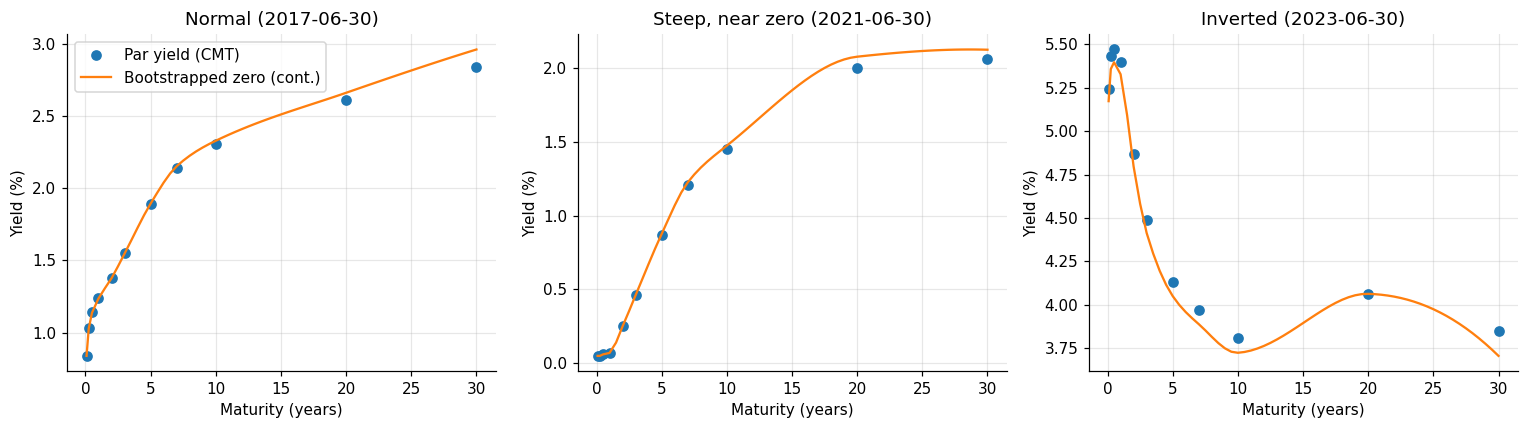

In [3]:
boot = {}
for label, d in DATES.items():
    curve = data.curve_on(d, cmt)
    boot[label] = (curve, *curves.bootstrap_zeros(curve.index.values, curve.values))

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
for ax, (label, (curve, taus, zeros)) in zip(axes, boot.items()):
    ax.plot(curve.index, curve.values * 100, "o", label="Par yield (CMT)")
    ax.plot(taus, zeros * 100, "-", label="Bootstrapped zero (cont.)")
    ax.set(title=label, xlabel="Maturity (years)", ylabel="Yield (%)")
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / "01_bootstrap.png", bbox_inches="tight")

## 2. Nelson-Siegel fit to the zero curve

$$z(\tau) = \beta_0 + \beta_1\frac{1-e^{-\lambda\tau}}{\lambda\tau} + \beta_2\left(\frac{1-e^{-\lambda\tau}}{\lambda\tau}-e^{-\lambda\tau}\right)$$

$\beta_0$ is the long-run level, $\beta_0+\beta_1$ the instantaneous short rate, and $\beta_2$ the hump.
For fixed $\lambda$ the model is linear in the betas, so the fit grid-searches $\lambda$ with least squares for the betas,
then refines all four jointly. This needs no starting values, unlike the original `nlsLM` fit.

The fit uses the bootstrapped zeros at the **quoted** maturities only, so spline-interpolated points don't get extra weight.
The closed-form instantaneous forward curve $f(0,\tau)$ is what Hull-White needs later.

*Note on 2023:* the 20-year point sits above both the 10- and 30-year. This is a known Treasury anomaly (the 20-year,
reintroduced in 2020, has traded cheap), not a data error, and no smooth three-factor curve can pass through it.
That is why the inverted date has the largest fit error.

In [4]:
ns_fits = {}
for label, (curve, taus, zeros) in boot.items():
    quoted = np.isin(np.round(taus, 6), np.round(curve.index.values, 6))
    ns_fits[label] = curves.fit_nelson_siegel(taus[quoted], zeros[quoted])

pd.DataFrame({label: {"beta0 (level, %)": f.b0 * 100, "beta1 (slope, %)": f.b1 * 100,
                      "beta2 (curvature, %)": f.b2 * 100, "lambda": f.lam,
                      "fit RMSE (bp)": f.rmse * BP}
              for label, f in ns_fits.items()}).round(3)

,Normal (2017-06-30),"Steep, near zero (2021-06-30)",Inverted (2023-06-30)
"beta0 (level, %)",3.218,2.489,3.656
"beta1 (slope, %)",-2.288,-2.429,1.328
"beta2 (curvature, %)",0.000,-2.753,3.603
lambda,0.239,0.533,2.130
fit RMSE (bp),5.848,3.296,11.110


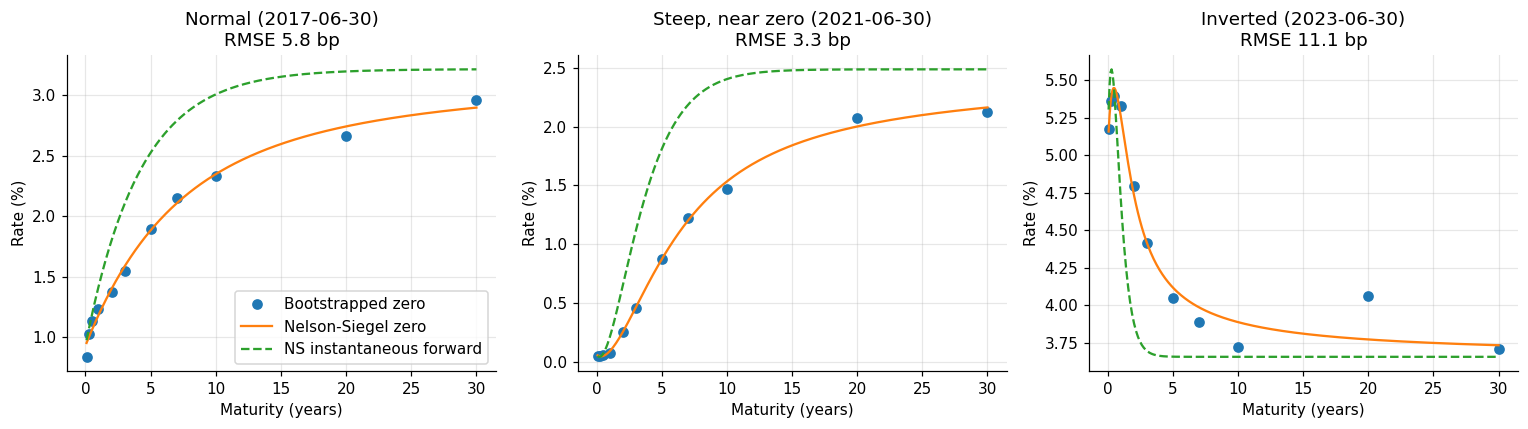

In [5]:
tau_fine = np.linspace(1 / 12, 30, 400)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (label, (curve, taus, zeros)) in zip(axes, boot.items()):
    fit = ns_fits[label]
    quoted = np.isin(np.round(taus, 6), np.round(curve.index.values, 6))
    ax.plot(taus[quoted], zeros[quoted] * 100, "o", label="Bootstrapped zero")
    ax.plot(tau_fine, fit.zero(tau_fine) * 100, "-", label="Nelson-Siegel zero")
    ax.plot(tau_fine, fit.forward(tau_fine) * 100, "--", label="NS instantaneous forward")
    ax.set(title=f"{label}\nRMSE {fit.rmse * BP:.1f} bp", xlabel="Maturity (years)", ylabel="Rate (%)")
axes[0].legend()
fig.tight_layout()
fig.savefig(FIG / "02_nelson_siegel.png", bbox_inches="tight")